In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import requests

In [122]:
uploaded = drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [124]:
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
url = f"https://query1.finance.yahoo.com/v8/finance/chart/SPY?range=20y&interval=1d"

res = requests.get(url, headers=headers)


In [125]:
data = res.json()

timestamp = data["chart"]["result"][0]["timestamp"]
indicators = data["chart"]["result"][0]["indicators"]
open = np.array(indicators["quote"][0]["open"])
high = np.array(indicators["quote"][0]["high"])
low = np.array(indicators["quote"][0]["low"])
close = np.array(indicators["quote"][0]["close"])
adjclose = np.array(indicators["adjclose"][0]["adjclose"])
volume = np.array(indicators["quote"][0]["volume"])

df = pd.DataFrame({"time": pd.to_datetime(timestamp, unit="s"),
                   "open": open,
                   "high": high,
                   "low": low,
                   "close": close,
                   "adjclose": adjclose,
                   "volume": volume.round(6)})

df.to_csv(index=False)

print("Head: ")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nShape: ")
print(df.shape)

print("\nDtypes: ")
print(df.dtypes)

print("\nDescribe: ")
print(df.describe())

Head: 
                 time        open        high         low       close   adjclose    volume
0 2006-09-14 13:30:00  131.960007  132.240005  131.750000  132.229996  91.562187  57805400
1 2006-09-15 13:30:00  132.309998  132.389999  131.679993  131.960007  91.777130  76703100
2 2006-09-18 13:30:00  131.789993  132.389999  131.649994  132.139999  91.902283  64154100
3 2006-09-19 13:30:00  132.119995  132.130005  131.070007  131.809998  91.672760  92089100
4 2006-09-20 13:30:00  132.250000  132.770004  132.059998  132.509995  92.159622  75204100

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      5030 non-null   datetime64[ns]
 1   open      5030 non-null   float64       
 2   high      5030 non-null   float64       
 3   low       5030 non-null   float64       
 4   close     5030 non-null   float64       
 5   adjclos

In [126]:
adjfactor = adjclose / close
adjopen = np.array(open) * adjfactor
adjhigh = np.array(high) * adjfactor
adjlow = np.array(low) * adjfactor
adjvolume = (np.array(volume) / adjfactor).astype(int)

data = pd.DataFrame({"time": pd.to_datetime(timestamp, unit="s"),
                   "open": adjopen,
                   "high": adjhigh,
                   "low": adjlow,
                   "close": adjclose,
                   "volume": adjvolume})

# high low spread
data["high_low_spread"] = (data["high"] - data["low"]) / data["close"]

# close open spread
data["close_open_spread"] = (data["close"] - data["open"]) / data["open"]

# volume change
data["volume_change"] = data["volume"].pct_change()

# 1 day return
data["return_1d"] = data["close"].pct_change()

#30 days return
data["return_30d"] = data["close"].pct_change(periods=30)

# SMA (Simple Moving Average) 200
data["sma_200"] = data["close"].rolling(window=200).mean()
data["dist_sma_200"] = (data["close"] - data["sma_200"]) / data["sma_200"]

# RSI
delta = data["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
data["rsi_14"] = 100 - (100 / (1 + rs))

data["return_ratio"] = data["return_1d"].shift(-1)

fractional_data = data[["time",
                        "high_low_spread",
                        "close_open_spread",
                        "volume_change",
                        "dist_sma_200",
                        "rsi_14",
                        "return_1d",
                        "return_30d"]].dropna()

fractional_data.to_csv(index=False)

In [133]:
print("Head: ")
print(fractional_data.head())

print("\nInfo:")
print(fractional_data.info())

print("\nShape: ")
print(fractional_data.shape)

print("\nDtypes: ")
print(fractional_data.dtypes)

print("\nDescribe: ")
print(fractional_data.describe())

Head: 
                   time  high_low_spread  close_open_spread  volume_change  dist_sma_200     rsi_14  return_1d  return_30d
199 2007-07-02 13:30:00         0.007576           0.006098      -0.482443      0.069184  59.385395   0.009041   -0.001152
200 2007-07-03 13:30:00         0.003348           0.001051      -0.477070      0.072208  54.192017   0.003623    0.002993
201 2007-07-05 13:30:00         0.006111          -0.001444       0.651834      0.070252  49.902779  -0.001050    0.002729
202 2007-07-06 13:30:00         0.008106           0.003937      -0.091511      0.075022  49.633272   0.005257    0.007868
203 2007-07-09 13:30:00         0.004833          -0.000392      -0.108014      0.074993  50.859961   0.000785    0.017873

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4831 entries, 199 to 5029
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               4831 non-nu

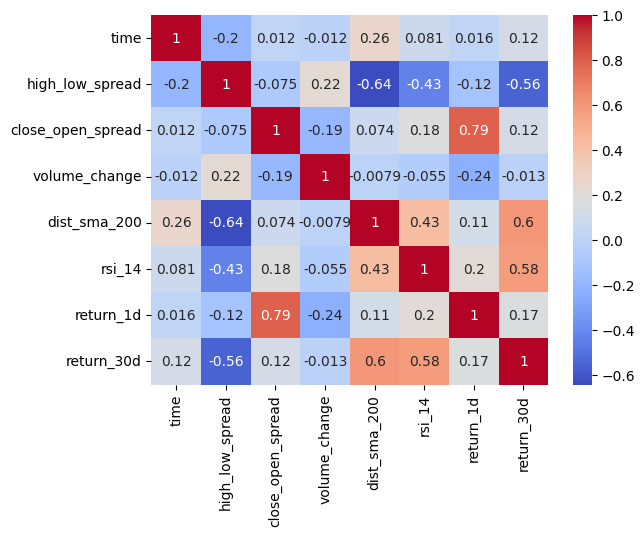

<class 'pandas.core.frame.DataFrame'>
Index: 4831 entries, 199 to 5029
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               4831 non-null   datetime64[ns]
 1   high_low_spread    4831 non-null   float64       
 2   close_open_spread  4831 non-null   float64       
 3   volume_change      4831 non-null   float64       
 4   dist_sma_200       4831 non-null   float64       
 5   rsi_14             4831 non-null   float64       
 6   return_1d          4831 non-null   float64       
 7   return_30d         4831 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 339.7 KB


,time,high_low_spread,close_open_spread,volume_change,dist_sma_200,rsi_14,return_1d,return_30d
199,2007-07-02 13:30:00,0.007576,0.006098,-0.482443,0.069184,59.385395,0.009041,-0.001152
200,2007-07-03 13:30:00,0.003348,0.001051,-0.477070,0.072208,54.192017,0.003623,0.002993
201,2007-07-05 13:30:00,0.006111,-0.001444,0.651834,0.070252,49.902779,-0.001050,0.002729
202,2007-07-06 13:30:00,0.008106,0.003937,-0.091511,0.075022,49.633272,0.005257,0.007868
203,2007-07-09 13:30:00,0.004833,-0.000392,-0.108014,0.074993,50.859961,0.000785,0.017873
...,...,...,...,...,...,...,...,...
5025,2026-09-08 13:30:00,0.005953,-0.004044,0.313967,0.078171,48.479287,-0.005492,0.036356
5026,2026-09-09 13:30:00,0.004630,-0.002199,-0.266698,0.072366,43.462909,-0.004648,0.029074
5027,2026-09-10 13:30:00,0.004579,-0.000264,0.302569,0.065109,45.137644,-0.005994,0.038892
5028,2026-09-11 13:30:00,0.003637,-0.000562,0.064035,0.073354,48.635238,0.008524,0.030471


In [127]:
correlation_matrix = fractional_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.show()

fractional_data.info()
fractional_data

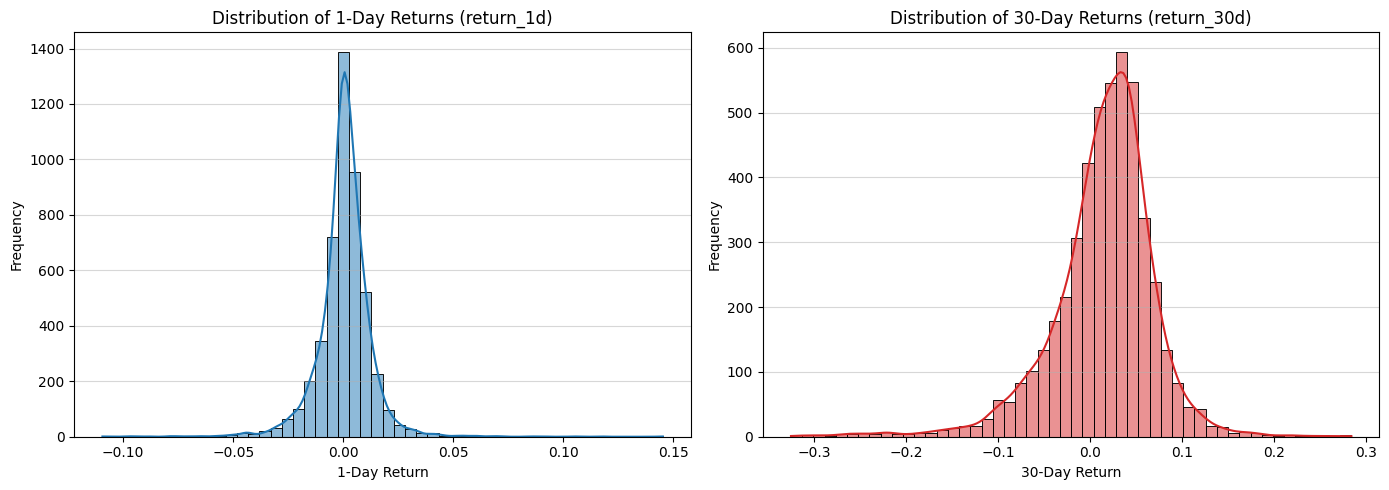

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(fractional_data["return_1d"], kde=True, ax=axes[0], color="tab:blue", bins=50)
axes[0].set_title("Distribution of 1-Day Returns (return_1d)", fontsize=12)
axes[0].set_xlabel("1-Day Return", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].grid(axis="y", alpha=0.5)

sns.histplot(fractional_data["return_30d"], kde=True, ax=axes[1], color="tab:red", bins=50)
axes[1].set_title("Distribution of 30-Day Returns (return_30d)", fontsize=12)
axes[1].set_xlabel("30-Day Return", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.show()

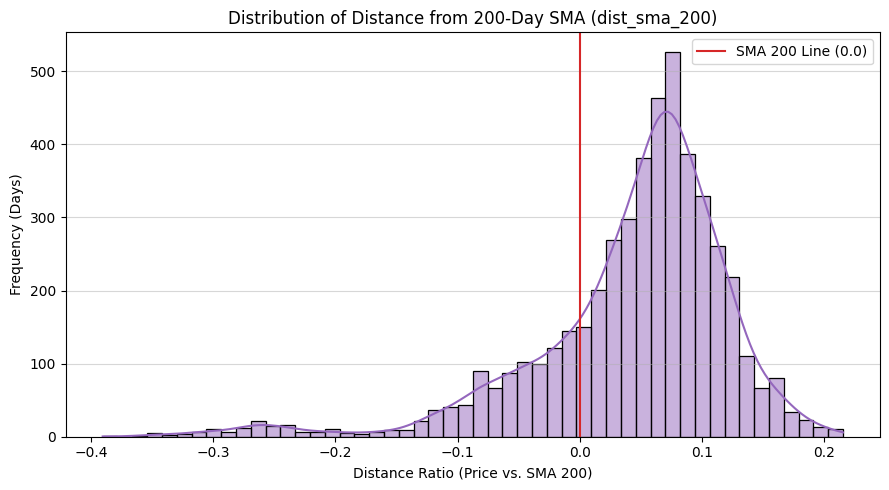

In [129]:
plt.figure(figsize=(9, 5))
sns.histplot(fractional_data["dist_sma_200"], kde=True, color="tab:purple", bins=50)

plt.axvline(0, color="tab:red", linewidth=1.5, label="SMA 200 Line (0.0)")

plt.title("Distribution of Distance from 200-Day SMA (dist_sma_200)", fontsize=12)
plt.xlabel("Distance Ratio (Price vs. SMA 200)", fontsize=10)
plt.ylabel("Frequency (Days)", fontsize=10)
plt.legend()
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

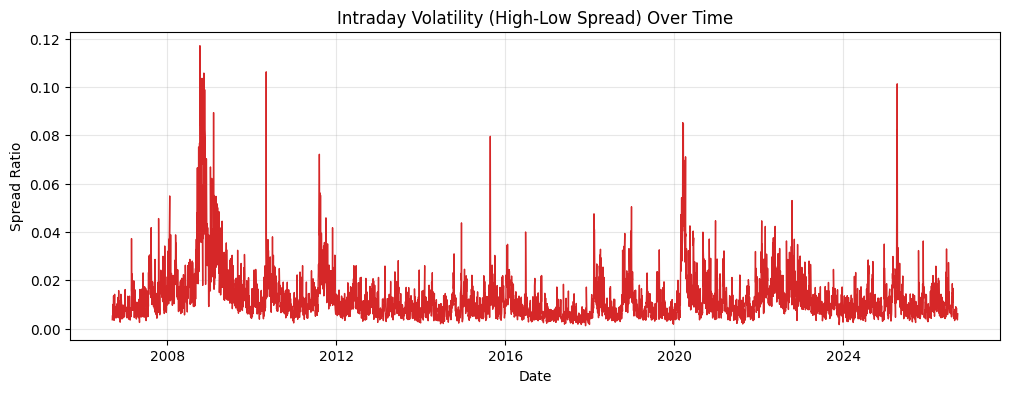

In [130]:
plt.figure(figsize=(12, 4))
plt.plot(data["time"], data["high_low_spread"], color="tab:red", linewidth=1)
plt.title("Intraday Volatility (High-Low Spread) Over Time")
plt.xlabel("Date")
plt.ylabel("Spread Ratio")
plt.grid(True, alpha=0.3)
plt.show()

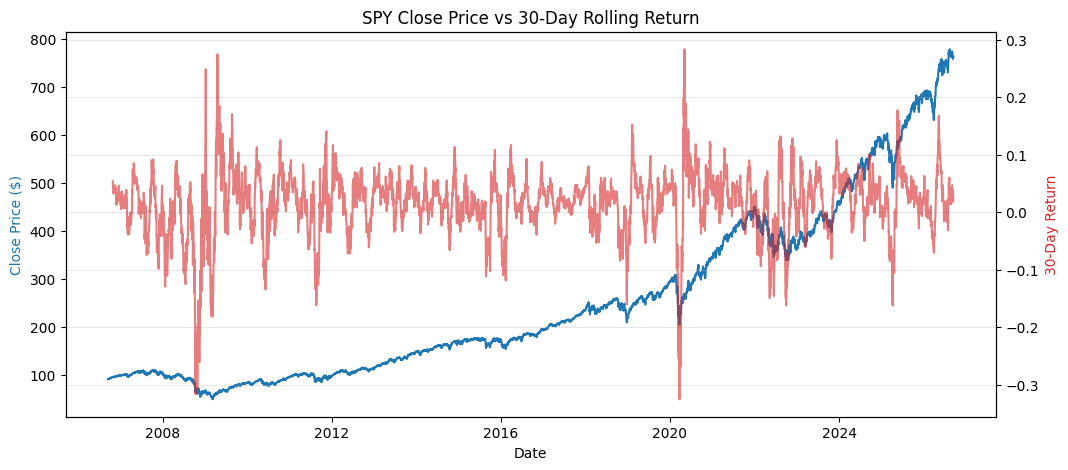

In [131]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Close Price ($)", color="tab:blue")
ax1.plot(data["time"], data["close"], color="tab:blue", label="Close Price")

ax2 = ax1.twinx()
ax2.set_ylabel("30-Day Return", color="tab:red")
ax2.plot(data["time"], data["return_30d"], color="tab:red", alpha=0.6, label="30-Day Return")

plt.title("SPY Close Price vs 30-Day Rolling Return")
plt.grid(True, alpha=0.3)
plt.show()

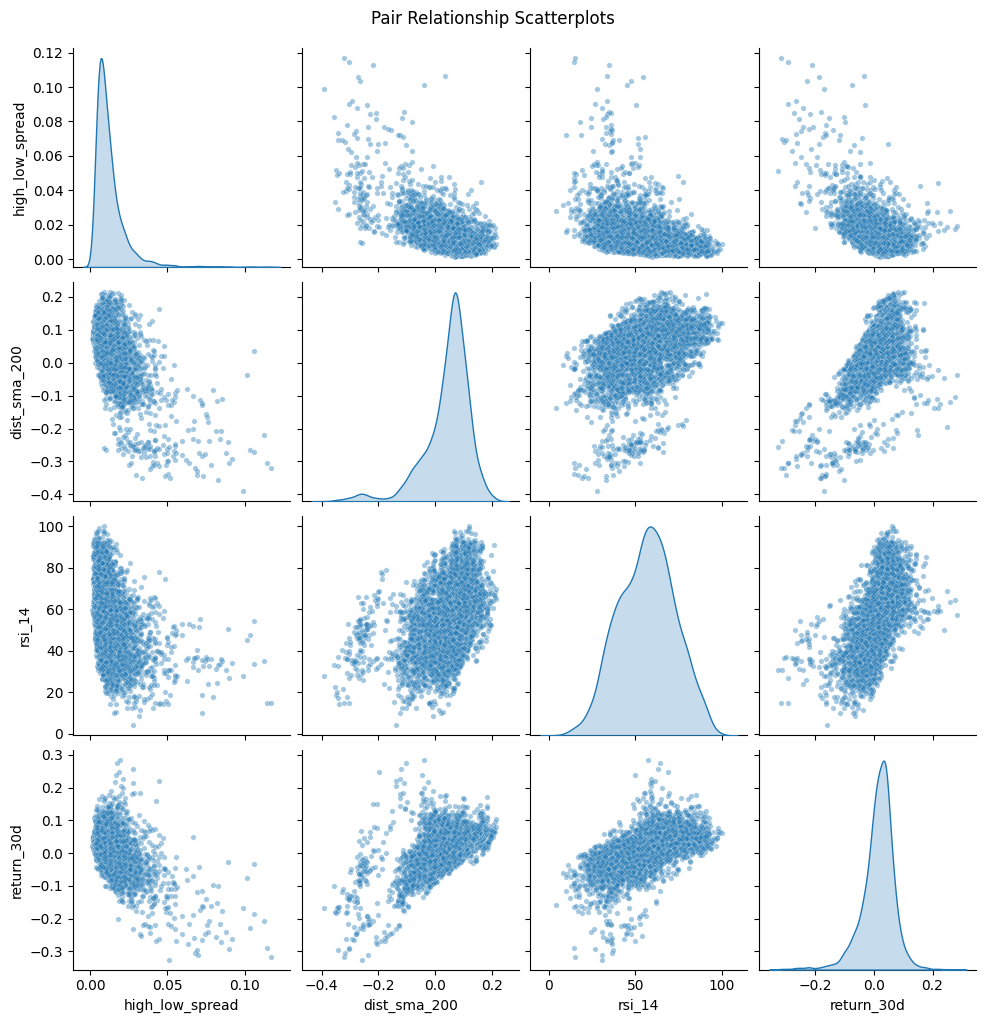

In [132]:
sns.pairplot(
    fractional_data[["high_low_spread", "dist_sma_200", "rsi_14", "return_30d"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)
plt.suptitle("Pair Relationship Scatterplots", y=1.02)
plt.show()